<a href="https://colab.research.google.com/github/cicadaxorg-cyber/projects/blob/main/stock_price_prediction_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#prakhar
print("---STAGE 1 : DATA COLLECTION ---")

import yfinance as yf
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
#bulk download of financial data
print(f"[*] Initiating massive data ingestion for: {tickers}")
bulk_data = yf.download(tickers, start="2016-05-01", end="2026-05-01", group_by='ticker',auto_adjust=True)
print("--- RAW STRUCTURE COLUMNS ---")
print(bulk_data.columns)
flattened_data = bulk_data.stack(level=0).reset_index()
flattened_data.rename(columns={'level_1': 'Ticker'}, inplace=True)
flattened_data.reset_index(drop=True, inplace=True)
print("\n--- CLEANED FLATTENED DATASET ---")
print(flattened_data.head(10))

print("\nDataset Dimensions (Rows, Columns):", flattened_data.shape)

---STAGE 1 : DATA COLLECTION ---
[*] Initiating massive data ingestion for: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']


[*********************100%***********************]  5 of 5 completed

--- RAW STRUCTURE COLUMNS ---
MultiIndex([( 'MSFT',   'Open'),
            ( 'MSFT',   'High'),
            ( 'MSFT',    'Low'),
            ( 'MSFT',  'Close'),
            ( 'MSFT', 'Volume'),
            ( 'AAPL',   'Open'),
            ( 'AAPL',   'High'),
            ( 'AAPL',    'Low'),
            ( 'AAPL',  'Close'),
            ( 'AAPL', 'Volume'),
            ('GOOGL',   'Open'),
            ('GOOGL',   'High'),
            ('GOOGL',    'Low'),
            ('GOOGL',  'Close'),
            ('GOOGL', 'Volume'),
            ( 'AMZN',   'Open'),
            ( 'AMZN',   'High'),
            ( 'AMZN',    'Low'),
            ( 'AMZN',  'Close'),
            ( 'AMZN', 'Volume'),
            ( 'NVDA',   'Open'),
            ( 'NVDA',   'High'),
            ( 'NVDA',    'Low'),
            ( 'NVDA',  'Close'),
            ( 'NVDA', 'Volume')],
           names=['Ticker', 'Price'])

--- CLEANED FLATTENED DATASET ---
Price       Date Ticker       Open       High        Low      Close    


/tmp/ipykernel_2655/2715690552.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  flattened_data = bulk_data.stack(level=0).reset_index()


In [ ]:
#prakhar
print("---STAGE 2 : COMPREHENSIVE DATA QUALITY & INTEGRITY AUDIT ---")

# 1. Handle Structural Duplicates
duplicate_count = flattened_data.duplicated(subset=['Date', 'Ticker']).sum()
print(f"[📋] Duplicate Rows Found: {duplicate_count}")

if duplicate_count > 0:
    print("    -> Removing duplicate records, keeping the first occurrence...")
    flattened_data.drop_duplicates(subset=['Date', 'Ticker'], keep='first', inplace=True)

# 2. Check for Missing (Null) Values
missing_counts = flattened_data.isnull().sum()
print("\n[📊] Missing Value Count Per Column:")
print(missing_counts)
if flattened_data.isnull().values.any():
    flattened_data.dropna(inplace=True)

# 3. Handle Impossible Outliers (Sanity Bound Checks)
# Let's check if any stock price is less than or equal to $0 (Mathematically impossible for these equities)
invalid_prices = (flattened_data['Close'] <= 0).sum()
print(f"\n[⚠️] Physically Impossible Prices (<= $0): {invalid_prices}")
flattened_data = flattened_data[flattened_data["Close"] > 0].copy()

# 4. Handle Statistical Outliers via Z-Score on Trading Volume
# Sudden massive trading volume spikes happen, but a Z-score > 10 means a probable data feed glitch.
# Group by Ticker so volumes aren't mixed together
ticker_groups = flattened_data.groupby('Ticker')['Volume']

volume_mean = ticker_groups.transform('mean')
volume_std = ticker_groups.transform('std')

# Calculate individual Z-scores
flattened_data['Volume_ZScore'] = (flattened_data['Volume'] - volume_mean) / volume_std
extreme_volume_glitches = (flattened_data['Volume_ZScore'].abs() > 5.0).sum()
print(f"[📊] Extreme Volume Outliers Detected (Z-Score > 5): {extreme_volume_glitches}")

---STAGE 2 : COMPREHENSIVE DATA QUALITY & INTEGRITY AUDIT ---
[📋] Duplicate Rows Found: 0

[📊] Missing Value Count Per Column:
Price
Date      0
Ticker    0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

[⚠️] Physically Impossible Prices (<= $0): 0
[📊] Extreme Volume Outliers Detected (Z-Score > 5): 44


In [ ]:
#prakhar
import numpy as np
print("--- STAGE 3: MATHEMATICAL DATA NORMALIZATION ---")

# 1. Ensure chronological sorting per ticker before running sequential calculations
flattened_data.sort_values(by=['Ticker', 'Date'], inplace=True)

# 2. Price Normalization: Compute Daily Log Returns per Ticker
# Formula: ln(Price_t / Price_t-1)
flattened_data['Log_Returns'] = flattened_data.groupby('Ticker')['Close'].apply(
    lambda x: np.log(x / x.shift(1))
).reset_index(level=0, drop=True)

# 3. Volume Normalization: Compute Z-Score Scaled Volume per Ticker
# Formula: (Volume - Ticker_Mean) / Ticker_Std
# This squishes massive raw share numbers into a normalized standard deviation scale (-3 to +3)
ticker_volume_groups = flattened_data.groupby('Ticker')['Volume']
volume_mean_per_ticker = ticker_volume_groups.transform('mean')
volume_std_per_ticker = ticker_volume_groups.transform('std')

flattened_data['Normalized_Volume'] = (flattened_data['Volume'] - volume_mean_per_ticker) / volume_std_per_ticker

# 4. Clean up NaN boundary values created by the shift(1) time-lag calculation
normalized_dataset = flattened_data.dropna().copy()

# 5. Verify the mathematical transformation
print("\n[✓] Normalization Complete.")
print(f"Final Matched Data Grid Shape: {normalized_dataset.shape}")
print("\nSample Preview of Normalized Feature Matrix (Apple & Nvidia):")
print(normalized_dataset[['Date', 'Ticker', 'Close', 'Log_Returns', 'Volume', 'Normalized_Volume']].head(10))

--- STAGE 3: MATHEMATICAL DATA NORMALIZATION ---

[✓] Normalization Complete.
Final Matched Data Grid Shape: (12565, 10)

Sample Preview of Normalized Feature Matrix (Apple & Nvidia):
Price       Date Ticker      Close  Log_Returns     Volume  Normalized_Volume
5     2016-05-03   AAPL  21.536564     0.016312  227325200           2.355122
10    2016-05-04   AAPL  21.312561    -0.010456  164102000           1.208969
15    2016-05-05   AAPL  21.226057    -0.004067  143562000           0.836606
20    2016-05-06   AAPL  21.107674    -0.005593  174799600           1.402902
25    2016-05-09   AAPL  21.123611     0.000755  131745600           0.622390
30    2016-05-10   AAPL  21.267025     0.006766  134747200           0.676805
35    2016-05-11   AAPL  21.059872    -0.009788  114876400           0.316574
40    2016-05-12   AAPL  20.565865    -0.023737  305258800           3.767956
45    2016-05-13   AAPL  20.606838     0.001990  177571200           1.453148
50    2016-05-16   AAPL  21.371744  

In [ ]:
#Pranav
print("Preview of features for the dashboard:")
display(normalized_dataset[['Date', 'Ticker', 'Close', 'Log_Returns', 'Normalized_Volume']].head())

# Calculate Moving Averages (5-day and 20-day) per Ticker
normalized_dataset['SMA_5'] = normalized_dataset.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=5).mean())
normalized_dataset['SMA_20'] = normalized_dataset.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=20).mean())

# Calculate Lagged Close Price (previous day's close) per Ticker
normalized_dataset['Prev_Close'] = normalized_dataset.groupby('Ticker')['Close'].shift(1)

# Calculate Target Variable (next day's close price) per Ticker
normalized_dataset['Target_Return'] = normalized_dataset.groupby('Ticker')['Close'].transform(lambda x: x.shift(-1) / x - 1)
normalized_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
normalized_dataset.dropna(inplace=True)

# Add Date-based Features
normalized_dataset['Year'] = normalized_dataset['Date'].dt.year
normalized_dataset['Month'] = normalized_dataset['Date'].dt.month
normalized_dataset['DayOfWeek'] = normalized_dataset['Date'].dt.dayofweek
normalized_dataset['DayOfYear'] = normalized_dataset['Date'].dt.dayofyear

# Drop rows with NaN values created by moving averages and lagged features
normalized_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
normalized_dataset.dropna(inplace=True)

print("Dataset Shape After Technical Indicators:")
print(normalized_dataset.shape)

print("New features added successfully. Preview of the updated dataset:")
display(normalized_dataset.head())

Preview of features for the dashboard:


Price,Date,Ticker,Close,Log_Returns,Normalized_Volume
5,2016-05-03,AAPL,21.536564,0.016312,2.355122
10,2016-05-04,AAPL,21.312561,-0.010456,1.208969
15,2016-05-05,AAPL,21.226057,-0.004067,0.836606
20,2016-05-06,AAPL,21.107674,-0.005593,1.402902
25,2016-05-09,AAPL,21.123611,0.000755,0.622390


Dataset Shape After Technical Indicators:
(12465, 18)
New features added successfully. Preview of the updated dataset:


Price,Date,Ticker,Open,High,Low,Close,Volume,Volume_ZScore,Log_Returns,Normalized_Volume,SMA_5,SMA_20,Prev_Close,Target_Return,Year,Month,DayOfWeek,DayOfYear
100,2016-05-31,AAPL,22.673904,22.856024,22.496337,22.733093,169228800,1.301911,-0.004895,1.301911,22.680279,21.623119,22.844645,-0.014020,2016,5,1,152
105,2016-06-01,AAPL,22.541866,22.660245,22.384789,22.414383,116693200,0.349510,-0.014119,0.349510,22.705776,21.667010,22.733093,-0.007516,2016,6,2,153
110,2016-06-02,AAPL,22.218602,22.273237,21.997781,22.245920,160766400,1.148499,-0.007544,1.148499,22.619269,21.713678,22.414383,0.002047,2016,6,3,154
115,2016-06-03,AAPL,22.261860,22.371131,22.184459,22.291454,114019600,0.301041,0.002045,0.301041,22.505899,21.766947,22.245920,0.007251,2016,6,4,155
120,2016-06-06,AAPL,22.307389,23.195223,22.207225,22.453085,93170000,-0.076935,0.007225,-0.076935,22.427587,21.834218,22.291454,0.004055,2016,6,0,158


In [ ]:
# ===========================
# ADVANCED TECHNICAL FEATURES
# ===========================

for ticker in normalized_dataset['Ticker'].unique():

    mask = normalized_dataset['Ticker'] == ticker

    df = normalized_dataset.loc[mask]

    # EMA
    normalized_dataset.loc[mask, 'EMA_10'] = (
        df['Close'].ewm(span=10).mean()
    )

    normalized_dataset.loc[mask, 'EMA_20'] = (
        df['Close'].ewm(span=20).mean()
    )

    # Volatility
    normalized_dataset.loc[mask, 'Volatility_10'] = (
        df['Log_Returns']
        .rolling(10)
        .std()
    )

    # Momentum
    normalized_dataset.loc[mask, 'Momentum_10'] = (
        df['Close'] -
        df['Close'].shift(10)
    )

    # RSI
    delta = df['Close'].diff()

    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss

    normalized_dataset.loc[mask, 'RSI_14'] = (
        100 - (100 / (1 + rs))
    )

normalized_dataset.dropna(inplace=True)

In [ ]:

#KESHAV
print("\n--- STAGE 4 : MODEL FITTING (PER-STOCK XGBOOST MODELS) ---")

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import pandas as pd

all_predictions = []
all_feature_importance = []

tickers = normalized_dataset['Ticker'].unique()

for ticker in tickers:

    print(f"\n{'='*60}")
    print(f"Training Model For: {ticker}")
    print(f"{'='*60}")

    stock_data = normalized_dataset[
        normalized_dataset['Ticker'] == ticker
    ].copy()

    stock_data.sort_values('Date', inplace=True)

    feature_columns = [
        'Close',
        'Log_Returns',
        'Normalized_Volume',
        'SMA_5',
        'SMA_20',
        'EMA_10',
        'EMA_20',
        'Volatility_10',
        'Momentum_10',
        'RSI_14'
    ]

    X = stock_data[feature_columns]
    y = stock_data['Target_Return']

    split_index = int(len(stock_data) * 0.80)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    print(f"Training Samples : {len(X_train)}")
    print(f"Testing Samples  : {len(X_test)}")

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    print(X_train.shape)

    print(X_train.isna().sum())

    print(np.isinf(X_train).sum())

    print(X_train.dtypes)

    print("\nChecking Training Data")

    print("NaN Count:")
    print(X_train.isna().sum().sum())

    print("Inf Count:")
    print(np.isinf(X_train).sum().sum())

    print("Target Std:")
    print(y_train.std())

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    current_prices = stock_data.iloc[split_index:]['Close'].values
    actual_prices = current_prices * (1 + y_test.values)

    predicted_prices = current_prices * (1 + predictions)

    stock_predictions = pd.DataFrame({
    'Ticker': ticker,
    'Date': stock_data.iloc[split_index:]['Date'].values,
    'Actual_Close': actual_prices,
    'Predicted_Close': predicted_prices
})

    all_predictions.append(stock_predictions)

    feature_importance = pd.DataFrame({
        'Ticker': ticker,
        'Feature': feature_columns,
        'Importance': model.feature_importances_
    })

    all_feature_importance.append(feature_importance)

    print("\nSample Predictions:")
    print(stock_predictions.head())

prediction_results = pd.concat(
    all_predictions,
    ignore_index=True
)

feature_importance_results = pd.concat(
    all_feature_importance,
    ignore_index=True
)

print("\n")
print("="*70)
print("ALL STOCK MODELS TRAINED SUCCESSFULLY")
print("="*70)

print("\nCombined Prediction Dataset Shape:")
print(prediction_results.shape)

print("\nPrediction Sample:")
print(prediction_results.head(10))

print("\nTop Feature Importance Across Stocks:")

top_features = (
    feature_importance_results
    .groupby('Feature')['Importance']
    .mean()
    .sort_values(ascending=False)
)

print(top_features)

print("\n[✓] Stage 4 Completed Successfully")


--- STAGE 4 : MODEL FITTING (PER-STOCK XGBOOST MODELS) ---

Training Model For: AAPL
Training Samples : 1984
Testing Samples  : 496
(1984, 10)
Price
Close                0
Log_Returns          0
Normalized_Volume    0
SMA_5                0
SMA_20               0
EMA_10               0
EMA_20               0
Volatility_10        0
Momentum_10          0
RSI_14               0
dtype: int64
Price
Close                0
Log_Returns          0
Normalized_Volume    0
SMA_5                0
SMA_20               0
EMA_10               0
EMA_20               0
Volatility_10        0
Momentum_10          0
RSI_14               0
dtype: int64
Price
Close                float64
Log_Returns          float64
Normalized_Volume    float64
SMA_5                float64
SMA_20               float64
EMA_10               float64
EMA_20               float64
Volatility_10        float64
Momentum_10          float64
RSI_14               float64
dtype: object

Checking Training Data
NaN Count:
0
Inf Count:


## STAGE 5: MODEL EVALUATION

In [ ]:
#Pavitra
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


print('\n--- STAGE 5: MODEL EVALUATION ---')

all_evaluations = []

for ticker in tickers:

    ticker_predictions = prediction_results[
        prediction_results['Ticker'] == ticker
    ]

    actuals = ticker_predictions['Actual_Close']
    predictions = ticker_predictions['Predicted_Close']

    mae = mean_absolute_error(actuals, predictions)
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(actuals, predictions)

    all_evaluations.append(
        {
            'Ticker': ticker,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
        }
    )

evaluation_df = pd.DataFrame(all_evaluations)

print('\n[✓] Evaluation Complete.')
print('\nModel Performance Per Ticker:')
display(evaluation_df)

print('\nAverage Model Performance Across All Tickers:')
display(evaluation_df.mean(numeric_only=True).to_frame(name='Average Performance'))

print('\n[✓] Stage 5 Completed Successfully')


--- STAGE 5: MODEL EVALUATION ---

[✓] Evaluation Complete.

Model Performance Per Ticker:


,Ticker,MAE,MSE,RMSE,R2
0,AAPL,3.224887,18.672068,4.321119,0.970793
1,AMZN,3.685955,23.836449,4.882259,0.949650
2,GOOGL,4.227430,35.119844,5.926200,0.990827
3,MSFT,5.407160,54.999064,7.416135,0.972596
4,NVDA,3.745186,22.589499,4.752841,0.976728



Average Model Performance Across All Tickers:


,Average Performance
MAE,4.058123
MSE,31.043385
RMSE,5.459711
R2,0.972119



[✓] Stage 5 Completed Successfully


## STAGE 6: VISUALIZATION OF PREDICTIONS


--- STAGE 6: VISUALIZATION OF PREDICTIONS ---


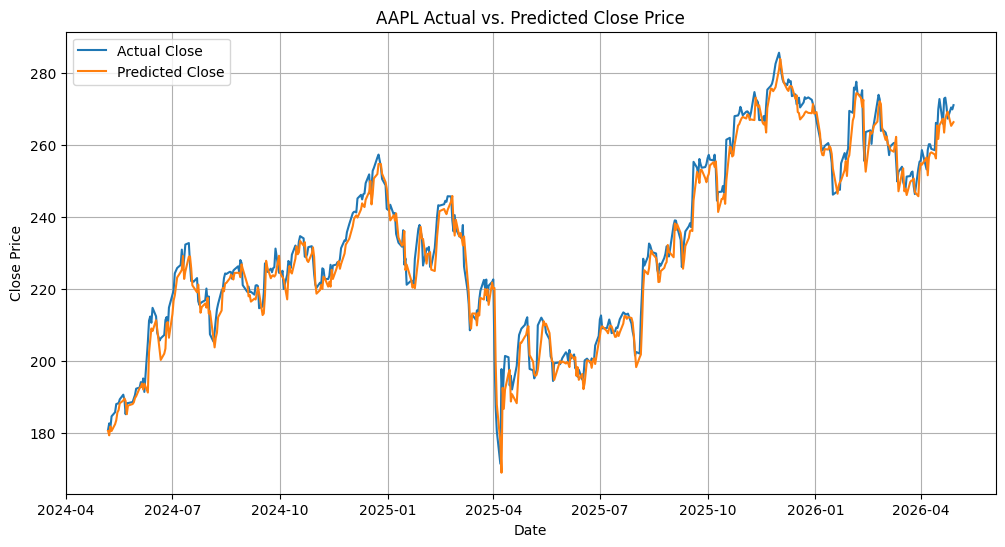

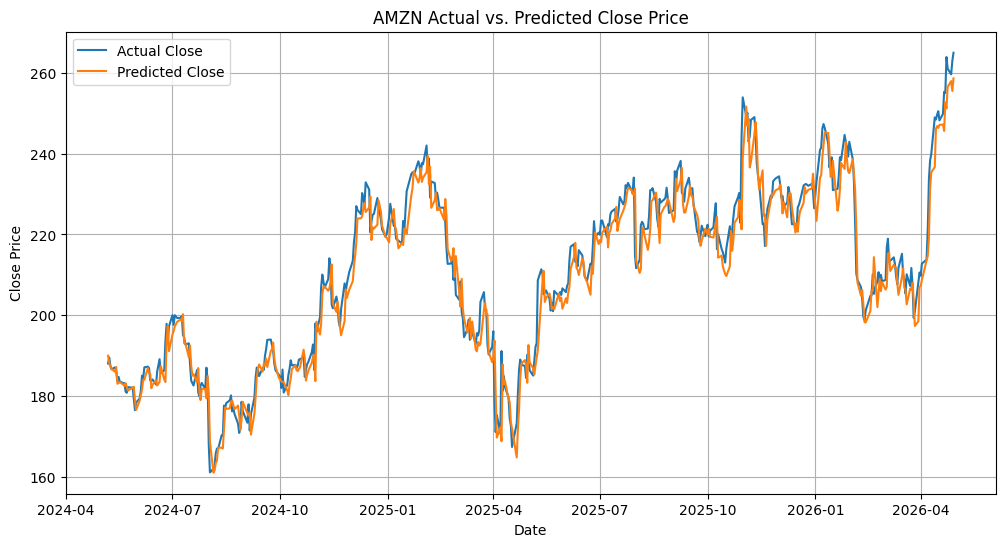

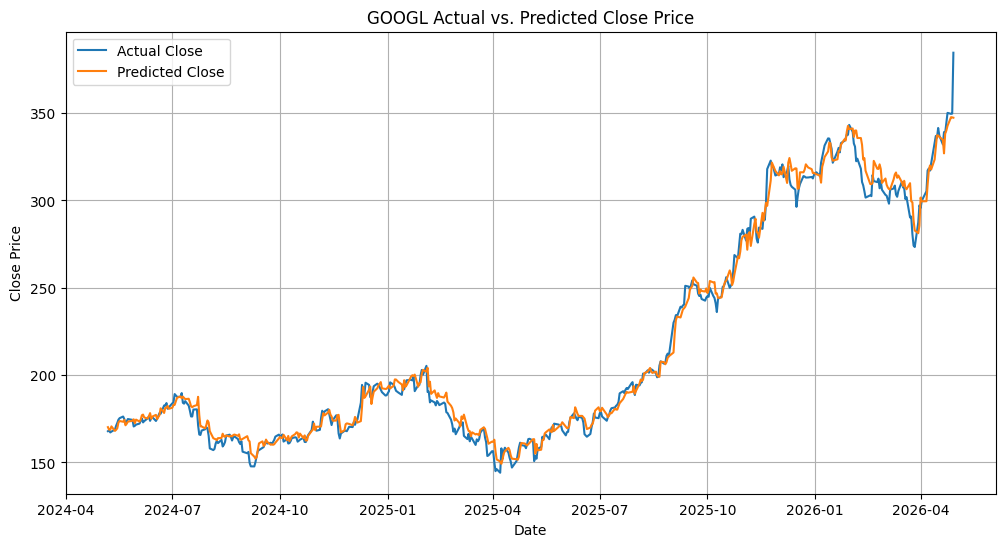

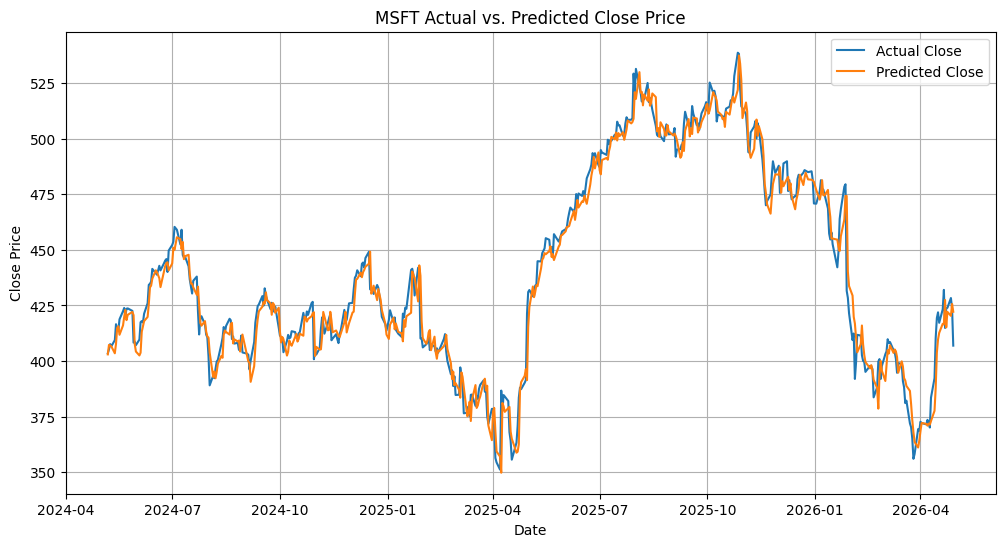

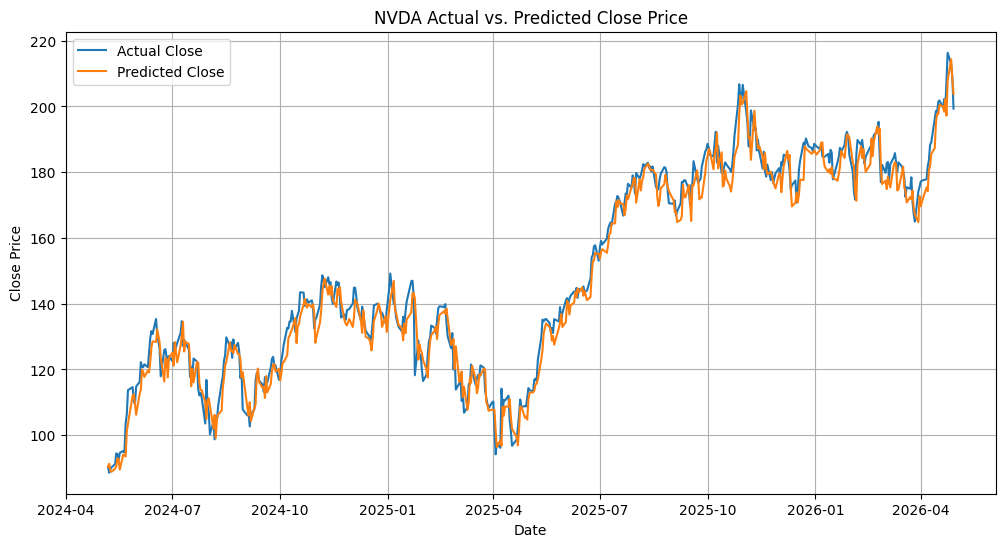


[✓] Stage 6 Completed Successfully


In [ ]:
#pavitra
import matplotlib.pyplot as plt
import seaborn as sns

print('\n--- STAGE 6: VISUALIZATION OF PREDICTIONS ---')

for ticker in tickers:
    ticker_predictions = prediction_results[prediction_results['Ticker'] == ticker]

    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Date', y='Actual_Close', data=ticker_predictions, label='Actual Close')
    sns.lineplot(x='Date', y='Predicted_Close', data=ticker_predictions, label='Predicted Close')
    plt.title(f'{ticker} Actual vs. Predicted Close Price')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.show()

print('\n[✓] Stage 6 Completed Successfully')

In [ ]:
print(stock_data[['Close','Target_Return']].head(10))
print(stock_data['Target_Return'].describe())
print(model.feature_importances_)

Price     Close  Target_Return
169    1.145346       0.017980
174    1.165939      -0.006097
179    1.158830      -0.000846
184    1.157849       0.026678
189    1.188738      -0.056919
194    1.121077      -0.010715
199    1.109064       0.014589
204    1.125244       0.016340
209    1.143631       0.007717
214    1.152456      -0.007445
count    2480.000000
mean        0.002574
std         0.031470
min        -0.187558
25%        -0.013368
50%         0.002826
75%         0.018712
max         0.298067
Name: Target_Return, dtype: float64
[0.08483151 0.08698054 0.09820863 0.08726937 0.11561321 0.10851499
 0.11645031 0.10043137 0.10775822 0.09394189]


In [ ]:
# Create a unified data layer for BI extraction
bi_export = normalized_dataset.copy()

# Add a column for dynamic time-window filtering in BI tools
bi_export['normalized_dataset'] = len(X_test)

# Export to a clean CSV file
bi_export.to_csv("stock_predictions_bi_layer.csv", index=False)
print("[✓] BI Data Layer Exported Successfully: 'stock_predictions_bi_layer.csv'")

[✓] BI Data Layer Exported Successfully: 'stock_predictions_bi_layer.csv'


In [ ]:
def generate_future_forecast(ticker_name, forecast_horizon_days=7):
    """
    Takes the absolute latest real market data point from the dataset,
    and recursively projects it into the future using the trained model.
    """
    # 1. Grab the latest row of real data for this stock (Today's closed market state)
    ticker_data = normalized_dataset[normalized_dataset['Ticker'] == ticker_name].sort_values('Date')
    latest_real_state = ticker_data.iloc[-1].copy()

    # Establish our starting baseline values
    current_close = latest_real_state['Close']
    current_date = pd.to_datetime(latest_real_state['Date'])

    # Track a history window of the last 20 days of prices to dynamically recalculate moving averages
    recent_price_history = ticker_data['Close'].tail(20).tolist()
    recent_log_returns = ticker_data['Log_Returns'].tail(10).tolist()

    future_records = []

    # 2. Run the Recursive Loop
    for day in range(1, forecast_horizon_days + 1):

        # Assemble our feature row exactly matching the columns your XGBoost model expects
        # We dynamically compute these features using our sliding window arrays
        current_features = pd.DataFrame([{
            'Close': current_close,
            'Log_Returns': recent_log_returns[-1],
            'Normalized_Volume': latest_real_state['Normalized_Volume'], # Keep volume anchored to recent base
            'SMA_5': np.mean(recent_price_history[-5:]),
            'SMA_20': np.mean(recent_price_history[-20:]),
            'EMA_10': latest_real_state['EMA_10'], # Carry over trend weights
            'EMA_20': latest_real_state['EMA_20'],
            'Volatility_10': np.std(recent_log_returns[-10:]),
            'Momentum_10': current_close - recent_price_history[-10],
            'RSI_14': latest_real_state['RSI_14'] # Baseline momentum anchor
        }])

        # Predict the next day's target return using your active trained XGBoost model
        predicted_return = model.predict(current_features)[0]

        # Convert that return decimal back into a raw future closing price
        next_close = current_close * (1 + predicted_return)
        next_log_return = np.log(next_close / current_close)

        # Step the calendar date forward, avoiding weekends
        current_date += pd.Timedelta(days=1)
        if current_date.weekday() >= 5: # If it lands on Saturday or Sunday, shift to Monday
            current_date += pd.Timedelta(days=2)

        # Append the forecast details to our results array
        future_records.append({
            'Ticker': ticker_name,
            'Date': current_date.strftime("%Y-%m-%d"),
            'Actual_Close': np.nan, # The market hasn't happened yet, so this stays blank
            'Predicted_Close': round(next_close, 2)
        })

        # Update our sliding price queues so the NEXT iteration loop calculates moving averages using this new step
        recent_price_history.append(next_close)
        recent_log_returns.append(next_log_return)
        current_close = next_close

    return pd.DataFrame(future_records)

In [ ]:
all_future_forecasts = []

# Generate future forecasts for every single ticker in your portfolio universe
for ticker in tickers:
    ticker_forecast = generate_future_forecast(ticker, forecast_horizon_days=7)
    all_future_forecasts.append(ticker_forecast)

# Combine all future projections into a single dataframe
future_predictions_df = pd.concat(all_future_forecasts, ignore_index=True)

# Format your historical prediction results dataframe to match the new future data schema
historical_predictions_df = prediction_results[['Ticker', 'Date', 'Actual_Close', 'Predicted_Close']].copy()

# Stack them vertically on top of each other
unified_dashboard_layer = pd.concat([historical_predictions_df, future_predictions_df], ignore_index=True)

# Export the updated matrix out as your new CSV file
unified_dashboard_layer.to_csv("stock_predictions_bi_layer.csv", index=False)

print("[✓] Process Complete. Your new data pipeline now includes true future horizons.")
print("\nPreviewing the blank-space future lines:")
print(unified_dashboard_layer[unified_dashboard_layer['Actual_Close'].isna()].head(10))

[✓] Process Complete. Your new data pipeline now includes true future horizons.

Previewing the blank-space future lines:
     Ticker        Date  Actual_Close  Predicted_Close
2480   AAPL  2026-04-30           NaN           268.86
2481   AAPL  2026-05-01           NaN           257.98
2482   AAPL  2026-05-04           NaN           257.66
2483   AAPL  2026-05-05           NaN           252.22
2484   AAPL  2026-05-06           NaN           248.72
2485   AAPL  2026-05-07           NaN           244.05
2486   AAPL  2026-05-08           NaN           239.71
2487   AMZN  2026-04-30           NaN           256.98
2488   AMZN  2026-05-01           NaN           255.22
2489   AMZN  2026-05-04           NaN           249.54



📊 SYSTEM REPORT FOR SIMULATION: NVDA
[🎯] Expected Close Price on 2026-05-05: $192.91



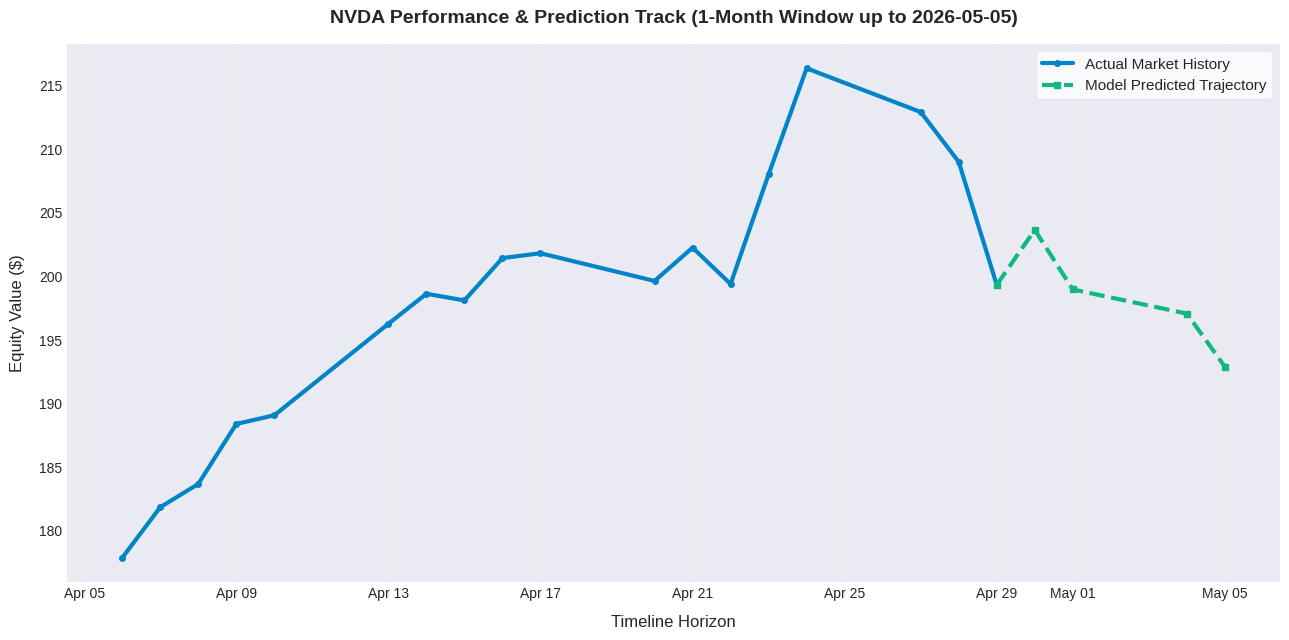

In [ ]:
# @title 📈 QuantPulse Interactive Prediction Cockpit { run: "auto" }
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the Interactive Form Inputs
chosen_ticker = "NVDA" # @param ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
target_prediction_date = "2026-05-05" # @param {type:"string"}

# 2. Parse selected dates and locate timeline boundaries
target_dt = pd.to_datetime(target_prediction_date)
start_history_dt = target_dt - pd.DateOffset(months=1)

# Filter our master prediction data layer for our specific stock universe
stock_universe = unified_dashboard_layer[unified_dashboard_layer['Ticker'] == chosen_ticker].copy()
stock_universe['Date'] = pd.to_datetime(stock_universe['Date'])

# 3. Extract the targeted rows within our 1-month historical window up to the chosen date
display_mask = (stock_universe['Date'] >= start_history_dt) & (stock_universe['Date'] <= target_dt)
chart_data = stock_universe[display_mask].sort_values('Date')

# 4. Extract the exact prediction scalar for our user text printout
specific_day_row = chart_data[chart_data['Date'] == target_dt]

print(f"\n{'='*60}")
print(f"📊 SYSTEM REPORT FOR SIMULATION: {chosen_ticker}")
print(f"{'='*60}")

if not specific_day_row.empty:
    expected_val = specific_day_row['Predicted_Close'].values[0]
    print(f"[🎯] Expected Close Price on {target_prediction_date}: ${expected_val:.2f}")
else:
    print(f"[⚠️] Note: {target_prediction_date} lands outside or on the exact boundary of our 7-day model horizon.")
    # Fallback to display closest available terminal projection price
    latest_available = chart_data.dropna(subset=['Predicted_Close']).iloc[-1]
    print(f"    -> Closest Projected Price ({latest_available['Date'].strftime('%Y-%m-%d')}): ${latest_available['Predicted_Close']:.2f}")

print(f"{'='*60}\n")

# 5. Generate the Custom Multi-Color Visualization Chart
plt.figure(figsize=(13, 6.5))
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')

# Plot real known historical data points (Solid Blue Line)
historical_data = chart_data[chart_data['Actual_Close'].notna()]
if not historical_data.empty:
    plt.plot(historical_data['Date'], historical_data['Actual_Close'],
             label='Actual Market History', color='#0284c7', linewidth=3, marker='o', markersize=4)

# Plot the model's future prediction trajectory (Dashed Emerald Green Line)
# We append the last historical point to the forecast path to ensure a continuous line link
forecast_data = chart_data[chart_data['Actual_Close'].isna()]
if not forecast_data.empty and not historical_data.empty:
    # Anchor step connection
    bridge_row = historical_data.iloc[[-1]].copy()
    bridge_row['Predicted_Close'] = bridge_row['Actual_Close']
    combined_forecast = pd.concat([bridge_row, forecast_data])

    plt.plot(combined_forecast['Date'], combined_forecast['Predicted_Close'],
             label='Model Predicted Trajectory', color='#10b981', linewidth=3, linestyle='--', marker='s', markersize=4)
elif not forecast_data.empty:
    plt.plot(forecast_data['Date'], forecast_data['Predicted_Close'],
             label='Model Predicted Trajectory', color='#10b981', linewidth=3, linestyle='--')

# Layout styling adjustments
plt.title(f"{chosen_ticker} Performance & Prediction Track (1-Month Window up to {target_prediction_date})",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline Horizon", fontsize=12, labelpad=10)
plt.ylabel("Equity Value ($)", fontsize=12, labelpad=10)

plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
plt.legend(frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Render plot to screen
plt.show()